# Duschinsky rotation and Franck–Condon factors: a worked example on water

This notebook walks through a complete vibronic-spectroscopy mini-workflow using `nma_jax`:

1.  Build two electronic states (ground "A" and a hypothetical bound excited "B") of water.
2.  Run a normal-mode analysis on each.
3.  Eckart-align the two geometries.
4.  Compute the Duschinsky rotation matrix $J$ and displacement vector $K$.
5.  Use the Huang–Rhys factors $S_k$ to build a Franck–Condon stick spectrum.
6.  Broaden it with a Gaussian lineshape.

### Background

For a vertical electronic transition between two harmonic states $A$ and $B$, the vibrational
wavefunctions of $B$ in the basis of $A$'s normal coordinates are related by an affine map
(Duschinsky 1937):

$$Q^{(B)} = J\, Q^{(A)} + K$$

where $J$ is an orthogonal $(M\times M)$ rotation (with $M = 3N-6$ for a non-linear molecule) and $K$
is the displacement of the equilibrium geometry of $B$, projected onto $B$'s normal coordinates.
In the **parallel-mode approximation** ($J = I$), the multidimensional Franck–Condon factor
factorises mode-by-mode, with each mode contributing a Poisson progression set by its Huang–Rhys
factor $S_k = K_k^2 / 2$ (in dimensionless coordinates):

$$|\langle 0|n_k\rangle|^2 = e^{-S_k}\, \frac{S_k^{n_k}}{n_k!}.$$

We use this approximation below to keep the demo compact. The full multidimensional treatment
needs the recursive formulas of Doktorov, Malkin & Manko (1977) — straightforward to add on top
of the $J$, $K$ outputs that `nma_jax` returns.

### Water as the demo molecule

Water's real $\tilde A\, {}^1B_1$ state is dissociative, so we instead construct a *bound* synthetic
excited state by stretching the O–H bonds and opening the bond angle, with softer harmonic
frequencies. The point is to demonstrate the API and the FC math, not to reproduce a specific
electronic transition.

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from nma_jax import Molecule, eckart_align, duschinsky
from nma_jax import core
from nma_jax.constants import ANGSTROM_BOHR, HFREQ_CM, FRED

np.set_printoptions(precision=4, suppress=True)

## 1.  Build two water states

We place the oxygen at the origin and the two hydrogens symmetrically about the $z$ axis in the
$y$–$z$ plane (so the molecule sits in standard $C_{2v}$ orientation). The geometry-builder takes
the O–H bond length in Å and the H–O–H angle in degrees.

In [2]:
def water_geom(roh_ang: float, ahoh_deg: float) -> np.ndarray:
    """H2O coordinates in Bohr, C2v with O at origin."""
    half = np.radians(ahoh_deg / 2.0)
    rb = roh_ang * ANGSTROM_BOHR
    return np.array([
        [0.0,              0.0,              0.0],
        [0.0,   rb * np.sin(half),  -rb * np.cos(half)],
        [0.0,  -rb * np.sin(half),  -rb * np.cos(half)],
    ])

MASSES = np.array([15.9994, 1.0078250319, 1.0078250319])
ANUMS  = [8, 1, 1]

# State A - ground state: experimental harmonic frequencies and geometry
# (Csaszar et al., J. Chem. Phys. 122, 214305 (2005))
coords_A = water_geom(roh_ang=0.9572, ahoh_deg=104.52)
freqs_A  = np.array([1648.47, 3832.17, 3942.53])     # nu2 (bend), nu1 (sym), nu3 (asym)

# State B - hypothetical bound excited state
coords_B = water_geom(roh_ang=1.10,   ahoh_deg=115.0)
freqs_B  = np.array([1100.0, 2800.0, 2900.0])

## 2.  Build a Cartesian Hessian for each state

Rather than running an electronic-structure code, we build a synthetic Hessian whose vibrational
spectrum reproduces a prescribed set of frequencies. The standard trick: assemble an orthonormal
basis whose first six columns span the translation/rotation subspace (which always has zero
eigenvalues), fill the remaining $3N-6$ columns with a random orthonormal completion, and place
the target eigenvalues on the diagonal of the mass-weighted Hessian in this basis.

In a real workflow you'd simply replace this step with `read_gaussian(...)` or `read_orca(...)`.

In [3]:
def synthetic_hessian(masses, coords, target_freqs_cm, *, seed):
    n = masses.shape[0]
    com = np.asarray(core.shift_to_com(jnp.array(masses), jnp.array(coords)))
    t = np.asarray(core.translation_vectors(jnp.array(masses)))
    r = np.asarray(core.rotation_vectors(jnp.array(masses), jnp.array(com)))
    rng = np.random.default_rng(seed)
    base = rng.standard_normal((3*n, 3*n))
    base[:, :6] = np.concatenate([t, r], axis=1)
    q, _ = np.linalg.qr(base)
    eig_au = (target_freqs_cm / HFREQ_CM) ** 2
    eig_full = np.concatenate([np.zeros(6), eig_au])
    h_mw = q @ np.diag(eig_full) @ q.T
    sqrt_m3 = np.sqrt(np.repeat(masses, 3))
    return h_mw * sqrt_m3[:, None] * sqrt_m3[None, :]

H_A = synthetic_hessian(MASSES, coords_A, freqs_A, seed=1)
H_B = synthetic_hessian(MASSES, coords_B, freqs_B, seed=2)

state_A = Molecule.from_arrays(atomic_numbers=ANUMS, masses=MASSES,
                               coords=coords_A, hessian=H_A)
state_B = Molecule.from_arrays(atomic_numbers=ANUMS, masses=MASSES,
                               coords=coords_B, hessian=H_B)

print(state_A)
print(state_B)

Molecule(n_atoms=3, formula='H2O', energy=None)
Molecule(n_atoms=3, formula='H2O', energy=None)


## 3.  Normal-mode analysis on each state

`Molecule.normal_modes()` projects out translation and rotation (the Sayvetz conditions), then
diagonalises the mass-weighted Hessian. We get back a `NormalModes` object with the
$3N-6$ frequencies (ascending), the mass-weighted and Cartesian normal-mode columns, and the
associated eigenvalues.

In [4]:
nm_A = state_A.normal_modes()
nm_B = state_B.normal_modes()

print("State A:", np.asarray(nm_A.frequencies), 'cm^-1')
print("State B:", np.asarray(nm_B.frequencies), 'cm^-1')

State A: [1648.47 3832.17 3942.53] cm^-1
State B: [1100. 2800. 2900.] cm^-1


## 4.  Eckart alignment

Before comparing two geometries' normal modes, we have to remove the rigid-body degrees of freedom
that aren't physical: any rigid translation + rotation of state B relative to state A. The
mass-weighted Eckart conditions minimise

$$\Phi(U) = \sum_a m_a \left\| R^{(B)}_a - U\, R^{(A)}_a \right\|^2$$

over proper rotations $U$. We solve this exactly via the Kabsch–Umeyama SVD with a
$\det = +1$ correction.

In [5]:
eck = eckart_align(state_A, state_B)
print(f"Mass-weighted RMSD after Eckart alignment: {eck.rmsd:.4f} Bohr")
print("Eckart rotation matrix:")
print(eck.rotation)

Mass-weighted RMSD after Eckart alignment: 0.1080 Bohr
Eckart rotation matrix:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]


## 5.  Duschinsky rotation and displacement

With both geometries in the same orientation, the Duschinsky matrix is built from the overlap
of the two sets of mass-weighted normal-mode columns; the displacement $K$ is the projection of
the (Eckart-aligned) geometry change onto $B$'s mass-weighted normal coordinates.

In [6]:
dus = duschinsky(nm_A, nm_B)
J = np.asarray(dus.J)
K = np.asarray(dus.K)
print("Duschinsky matrix J  (rows: state B modes, columns: state A modes)")
print(J)
print()
print("Displacement K (mass-weighted, atomic units):", K)
print(f"|det(J)| = {abs(np.linalg.det(J)):.4f}")

Duschinsky matrix J  (rows: state B modes, columns: state A modes)
[[-0.2869  0.2523  0.9235]
 [-0.6413  0.6659 -0.3802]
 [ 0.71    0.6991  0.0324]]

Displacement K (mass-weighted, atomic units): [0.3543 0.2868 0.0484]
|det(J)| = 0.9960


$|J|$ tells you how the modes mix. Off-diagonal entries near 1 indicate that a mode in state $B$
is almost entirely a *different* mode of state $A$ — a strong Duschinsky effect that the
parallel-mode approximation will fail to capture in the spectrum.

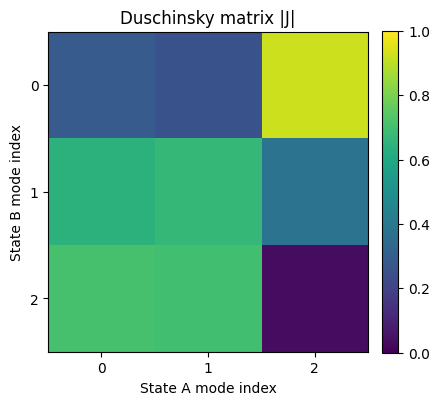

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = ax.imshow(np.abs(J), cmap='viridis', vmin=0, vmax=1)
ax.set_title("Duschinsky matrix |J|")
ax.set_xlabel("State A mode index")
ax.set_ylabel("State B mode index")
ax.set_xticks(range(3));  ax.set_yticks(range(3))
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout();  plt.show()

## 6.  Huang–Rhys factors

Converting $K$ to dimensionless normal-coordinate displacements $\delta_k$:

$$\delta_k = \sqrt{\omega_k / \hbar}\, K_k,  \qquad  S_k = \delta_k^2 / 2.$$

`nma_jax.constants.FRED` is the unit-conversion prefactor that takes $\omega$ in cm$^{-1}$ and $K$ in
atomic units to a dimensionless $\delta$.

In [8]:
freqs_B_arr = np.asarray(nm_B.frequencies)
delta = FRED * np.sqrt(freqs_B_arr) * K
S = 0.5 * delta ** 2

print(f"{'mode':>4s}  {'omega (cm^-1)':>14s}  {'delta':>10s}  {'S':>10s}")
for i, (om, d, s) in enumerate(zip(freqs_B_arr, delta, S)):
    print(f"{i:>4d}  {om:14.1f}  {d:10.4f}  {s:10.4f}")

mode   omega (cm^-1)       delta           S
   0          1100.0      1.0708      0.5733
   1          2800.0      1.3832      0.9567
   2          2900.0      0.2374      0.0282


## 7.  Stick spectrum in the parallel-mode approximation

In the $J = I$ limit, the multidimensional FC factor is a product over modes of single-mode
Poisson factors. We enumerate all $(n_1, n_2, n_3)$ progressions up to $n_\max$ and combine.

(Total intensity should equal 1 by closure: $\sum_n |\langle 0|n\rangle|^2 = 1$ for each mode.)

In [9]:
from math import factorial
from itertools import product

def stick_spectrum(huang_rhys, freqs, n_max=6):
    n_modes = len(huang_rhys)
    fcfs = [np.array([np.exp(-S) * S**n / factorial(n) for n in range(n_max + 1)])
            for S in huang_rhys]
    energies, intensities = [], []
    for combo in product(range(n_max + 1), repeat=n_modes):
        energies.append(sum(n * freqs[k] for k, n in enumerate(combo)))
        intensities.append(np.prod([fcfs[k][n] for k, n in enumerate(combo)]))
    return np.array(energies), np.array(intensities)

energies, intens = stick_spectrum(S, freqs_B_arr, n_max=6)
order = np.argsort(energies)
energies, intens = energies[order], intens[order]
keep = intens > 1e-6
energies, intens = energies[keep], intens[keep]

print(f"{len(energies)} non-negligible transitions")
print(f"  Strongest:  E = {energies[np.argmax(intens)]:.1f} cm^-1, I = {intens.max():.4f}")
print(f"  Total intensity = {intens.sum():.4f}  (should be ~1)")

95 non-negligible transitions
  Strongest:  E = 0.0 cm^-1, I = 0.2105
  Total intensity = 0.9999  (should be ~1)


## 8.  Gaussian-broadened spectrum

Real spectra have finite linewidths (lifetime + inhomogeneous broadening). We convolve the stick
spectrum with a Gaussian — FWHM 200 cm$^{-1}$ here is a reasonable proxy for room-temperature
condensed-phase linewidths.

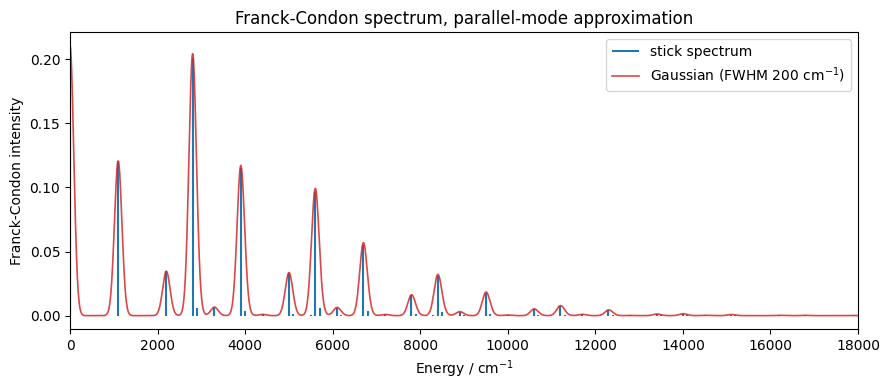

In [10]:
e_grid = np.linspace(0, 25_000, 4000)
fwhm = 200.0
sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
spectrum = np.zeros_like(e_grid)
for e, i in zip(energies, intens):
    spectrum += i * np.exp(-(e_grid - e) ** 2 / (2 * sigma ** 2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.vlines(energies, 0, intens, color='C0', lw=1.5, label='stick spectrum')
ax.plot(e_grid, spectrum / spectrum.max() * intens.max(),
        color='C3', lw=1.2, alpha=0.85, label=f'Gaussian (FWHM {fwhm:.0f} cm$^{{-1}}$)')
ax.set_xlim(0, 18_000)
ax.set_xlabel('Energy / cm$^{-1}$')
ax.set_ylabel('Franck-Condon intensity')
ax.set_title('Franck-Condon spectrum, parallel-mode approximation')
ax.legend()
plt.tight_layout();  plt.show()

## What to do next

* **Replace the synthetic Hessians with real calculations**: drop in `read_gaussian("freq.log", "freq.fchk")` or
  `read_orca("freq.hess", "freq.out")` for each state and the rest of the notebook is unchanged.
* **Go beyond the parallel-mode approximation**: the $J$, $K$ outputs we have here are exactly the
  inputs to the Doktorov–Malkin–Manko recursive formulas for full multidimensional FCFs with
  Duschinsky mixing. The package gives you $J$ and $K$ cleanly; the recursion is ~50 lines of
  Python.
* **Vibronic spectra at finite temperature**: extend with Boltzmann-weighted sums over initial
  vibrational quanta on the ground state.

The reason the math here is small enough to fit in a notebook is that `nma_jax` puts the heavy
machinery (mass-weighted Hessian, trans/rot projection, Eckart alignment, Duschinsky overlap) in
one library call each.